# Toy DAG demo

Four `Source` artifacts (real Project Gutenberg texts) feeding a `Tokenizer`
trained on three of them, a `TokenizedSource` per source, a `DataSet` for the
run, and two `Pretraining` legs, the second continuing the first.

Every artifact owns one folder; its files and its `manifest.json` both live
there. Jobs take their inputs from `deps()` -- nothing about "which sources
feed the tokenizer" is declared on the job itself.

Five sections, bottom up: the **plan** (the jobs that would produce a request),
the **manifest** (what an artifact is, written down), **loading** one back from
disk, **checking and declaring** it against a root, and **visualizing** the
result.

In [1]:
import json
from pathlib import Path

from artifact import (
    MANIFEST,
    Artifact,
    DataSet,
    Pretraining,
    PretrainingConfig,
    Source,
    Tokenizer,
)
from resolve import check, declare, job_list, resolve, run_all, status
from visualizer import visualize

root = Path("../data_demo")  # kept separate from the real /data tree

In [2]:
odyssey = Source(
    name="odyssey", url="https://www.gutenberg.org/cache/epub/1727/pg1727.txt"
)
mobydick = Source(
    name="mobydick", url="https://www.gutenberg.org/cache/epub/2701/pg2701.txt"
)
romeojuliet = Source(
    name="romeojuliet", url="https://www.gutenberg.org/cache/epub/1513/pg1513.txt"
)
montecristo = Source(
    name="montecristo", url="https://www.gutenberg.org/cache/epub/1184/pg1184.txt"
)

In [3]:
RUN_ID = "toy"

tokenizer = Tokenizer(
    vocab_size=50,
    kind="bpe",
    special_tokens=("<pad>", "<unk>"),
    sources=(odyssey, mobydick, montecristo),
)

training_split = DataSet.from_sources(
    run_id=RUN_ID,
    tokenizer=tokenizer,
    train_sources=[
        odyssey,
        mobydick,
    ],
    valid_sources=[
        romeojuliet,
        montecristo,
    ],
)

cfg = PretrainingConfig(
    hidden_size=64, num_layers=2, lr=1e-3, seed=1, checkpoint_every=250
)

# a run is a chain of legs, each continuing the model the one before it
# produced. leg1 omits `model` -- the loop initializes its own weights, no
# separate artifact needed for that. where a chain is cut is operational -- a
# container doesn't live forever -- not scientific: with seeds carried
# deterministically, 0->2000 and 0->1000->2000 land on the same weights.
leg1 = Pretraining(
    run_id=RUN_ID, dataset=training_split, tokenizer=tokenizer, config=cfg, step=1000
)
leg2 = Pretraining(
    run_id=RUN_ID, dataset=training_split, tokenizer=tokenizer, config=cfg,
    step=2000, model=leg1,
)
pretraining = leg2  # the request the rest of the notebook resolves

pretraining  # parameters all the way down; `commit` is hidden from the repr

Pretraining(run_id='toy', dataset=DataSet(run_id='toy', train_set=(TokenizedSource(tokenizer=Tokenizer(vocab_size=50, special_tokens=('<pad>', '<unk>'), sources=(Source(name='odyssey', url='https://www.gutenberg.org/cache/epub/1727/pg1727.txt'), Source(name='mobydick', url='https://www.gutenberg.org/cache/epub/2701/pg2701.txt'), Source(name='montecristo', url='https://www.gutenberg.org/cache/epub/1184/pg1184.txt')), kind='bpe'), source=Source(name='odyssey', url='https://www.gutenberg.org/cache/epub/1727/pg1727.txt')), TokenizedSource(tokenizer=Tokenizer(vocab_size=50, special_tokens=('<pad>', '<unk>'), sources=(Source(name='odyssey', url='https://www.gutenberg.org/cache/epub/1727/pg1727.txt'), Source(name='mobydick', url='https://www.gutenberg.org/cache/epub/2701/pg2701.txt'), Source(name='montecristo', url='https://www.gutenberg.org/cache/epub/1184/pg1184.txt')), kind='bpe'), source=Source(name='mobydick', url='https://www.gutenberg.org/cache/epub/2701/pg2701.txt'))), valid_set=(Toke

## The plan

`resolve()` sits on top of the artifact tree and attaches the job that produces
each node. It's a pure function of the request: it never looks at the disk,
prunes nothing that already exists, and is never written anywhere.

The plan is what runs; the manifest (next section) is what lands on disk. A plan
node carries a live `Job` the manifest doesn't, and lacks the commit the
manifest has.

In [4]:
pretraining_plan = resolve(pretraining)
tokenizer_plan = resolve(tokenizer)

In [5]:
tokenizer_plan  # artifact, its job, and a plan per dependency

{'artifact': Tokenizer(vocab_size=50, special_tokens=('<pad>', '<unk>'), sources=(Source(name='odyssey', url='https://www.gutenberg.org/cache/epub/1727/pg1727.txt'), Source(name='mobydick', url='https://www.gutenberg.org/cache/epub/2701/pg2701.txt'), Source(name='montecristo', url='https://www.gutenberg.org/cache/epub/1184/pg1184.txt')), kind='bpe'),
 'job': <job.TokenizerJob at 0x1078e9fa0>,
 'dependencies': [{'artifact': Source(name='odyssey', url='https://www.gutenberg.org/cache/epub/1727/pg1727.txt'),
   'job': <job.SourceJob at 0x10789e150>,
   'dependencies': []},
  {'artifact': Source(name='mobydick', url='https://www.gutenberg.org/cache/epub/2701/pg2701.txt'),
   'job': <job.SourceJob at 0x10789cd10>,
   'dependencies': []},
  {'artifact': Source(name='montecristo', url='https://www.gutenberg.org/cache/epub/1184/pg1184.txt'),
   'job': <job.SourceJob at 0x10789e3c0>,
   'dependencies': []}]}

In [6]:
# flattened into the order the work would happen in, each artifact asked what
# the disk says. job_list dedups by folder, so the tokenizer appears once even
# though four tokenized sources reach it.
for job in job_list(pretraining_plan):
    print(f"{status(job.artifact, root):11}{type(job).__name__:18} {job.artifact.artifact_path}")

done       SourceJob          sources/odyssey
done       SourceJob          sources/mobydick
done       SourceJob          sources/montecristo
done       TokenizerJob       tokenizers/bpe-50-2b209d180c
done       TokenizeSourceJob  tokenizers/bpe-50-2b209d180c/bin/odyssey
done       TokenizeSourceJob  tokenizers/bpe-50-2b209d180c/bin/mobydick
done       SourceJob          sources/romeojuliet
done       TokenizeSourceJob  tokenizers/bpe-50-2b209d180c/bin/romeojuliet
done       TokenizeSourceJob  tokenizers/bpe-50-2b209d180c/bin/montecristo
done       DataSetJob         runs/toy/dataset
done       PretrainJob        runs/toy/pretraining/step-1000
done       PretrainJob        runs/toy/pretraining/step-2000


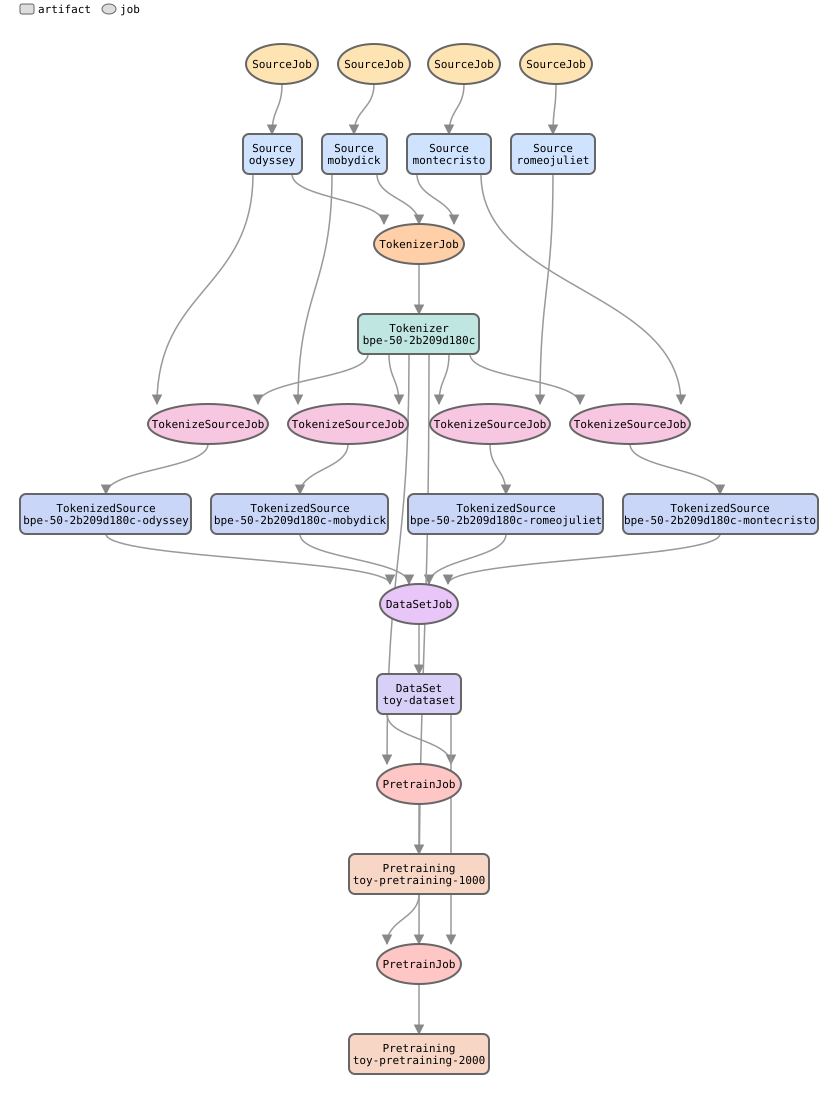

In [7]:
visualize(resolve(pretraining))

## The manifest

Four keys: what it is, the commit its jobs run from, its own parameters, and a
manifest apiece for what it's built from. Nothing derivable is recorded -- no
path, no filenames, no job -- because a recorded derivation is a second answer
that can disagree with the first.

In [8]:
print(json.dumps(tokenizer.manifest(), indent=2))

{
  "artifact": "Tokenizer",
  "commit": "d9479be984089f2c74ffe078793f3f1f06fad4f0-dirty",
  "parameters": {
    "kind": "bpe",
    "special_tokens": [
      "<pad>",
      "<unk>"
    ],
    "vocab_size": 50
  },
  "dependencies": {
    "sources": [
      {
        "artifact": "Source",
        "commit": "d9479be984089f2c74ffe078793f3f1f06fad4f0-dirty",
        "parameters": {
          "name": "odyssey",
          "url": "https://www.gutenberg.org/cache/epub/1727/pg1727.txt"
        },
        "dependencies": {}
      },
      {
        "artifact": "Source",
        "commit": "d9479be984089f2c74ffe078793f3f1f06fad4f0-dirty",
        "parameters": {
          "name": "mobydick",
          "url": "https://www.gutenberg.org/cache/epub/2701/pg2701.txt"
        },
        "dependencies": {}
      },
      {
        "artifact": "Source",
        "commit": "d9479be984089f2c74ffe078793f3f1f06fad4f0-dirty",
        "parameters": {
          "name": "montecristo",
          "url": "https://www

In [9]:
# what the manifest buys, in three lines
same = Artifact.from_manifest(tokenizer.manifest())
print("rebuilt from its own manifest    :", same == tokenizer)
print("...and re-serializes identically :", same.manifest() == tokenizer.manifest())
print("commit isn't part of identity    :", tokenizer.commit[:7], "but ==  ignores it")

rebuilt from its own manifest    : True
...and re-serializes identically : True
commit isn't part of identity    : d9479be but ==  ignores it


## Checking and declaring

Manifests are written **ahead of the work**, for the whole graph, and are
immutable once written. `check` resolves a request and reconciles it against a
root without touching anything; `Declaration.write()` declares whatever isn't
there yet, and only if nothing is inconsistent.

Six statuses, dependency-ordered:

| | |
|---|---|
| `new` | nothing there; `write` will declare it |
| `declared` | manifest agrees, no outputs yet |
| `partial` | manifest agrees, some outputs |
| `done` | manifest agrees, every output present |
| `conflict` | a manifest is there and describes something else |
| `undeclared` | outputs nobody declared |

Only `conflict` and `undeclared` block. Commit drift is reported but allowed,
unless you pass `strict_commit=True`.

In [25]:
# before declaring: the shared artifacts (sources, tokenizer, dataset) are
# already produced and reused as-is; the two legs are new
print(check(pretraining, root))

run toy under ../data_demo
  done       sources/odyssey
  done       sources/mobydick
  done       sources/montecristo
  done       tokenizers/bpe-50-2b209d180c
  done       tokenizers/bpe-50-2b209d180c/bin/odyssey
  done       tokenizers/bpe-50-2b209d180c/bin/mobydick
  done       sources/romeojuliet
  done       tokenizers/bpe-50-2b209d180c/bin/romeojuliet
  done       tokenizers/bpe-50-2b209d180c/bin/montecristo
  done       runs/toy/dataset
  done       runs/toy/pretraining/step-1000
  done       runs/toy/pretraining/step-2000

12 done
ok -- 0 to declare


In [11]:
# declare() checks then writes; the Declaration it returns is a snapshot from
# just before the write, so it still reads "new". A fresh check() shows what's
# really on disk now: declared, not yet done.
declare(pretraining, root)
print(check(pretraining, root))

run toy under ../data_demo
  done       sources/odyssey
  done       sources/mobydick
  done       sources/montecristo
  done       tokenizers/bpe-50-2b209d180c
  done       tokenizers/bpe-50-2b209d180c/bin/odyssey
  done       tokenizers/bpe-50-2b209d180c/bin/mobydick
  done       sources/romeojuliet
  done       tokenizers/bpe-50-2b209d180c/bin/romeojuliet
  done       tokenizers/bpe-50-2b209d180c/bin/montecristo
  done       runs/toy/dataset
  done       runs/toy/pretraining/step-1000
  done       runs/toy/pretraining/step-2000

12 done
ok -- 0 to declare


In [12]:
# declaring again is a no-op: a fresh check() sees `declared`, not `new`, so
# write() has nothing left to write
print("second declare, nothing new:", declare(pretraining, root).write())

second declare, nothing new: []


In [13]:
# run_all's own return value is the pre-run snapshot from declare() -- same
# staleness as above. A fresh check() after is what actually confirms done.
run_all(pretraining, root)
print()
print(check(pretraining, root))

skip  sources/odyssey  (already done)
skip  sources/mobydick  (already done)
skip  sources/montecristo  (already done)
skip  tokenizers/bpe-50-2b209d180c  (already done)
skip  tokenizers/bpe-50-2b209d180c/bin/odyssey  (already done)
skip  tokenizers/bpe-50-2b209d180c/bin/mobydick  (already done)
skip  sources/romeojuliet  (already done)
skip  tokenizers/bpe-50-2b209d180c/bin/romeojuliet  (already done)
skip  tokenizers/bpe-50-2b209d180c/bin/montecristo  (already done)
skip  runs/toy/dataset  (already done)
skip  runs/toy/pretraining/step-1000  (already done)
skip  runs/toy/pretraining/step-2000  (already done)

run toy under ../data_demo
  done       sources/odyssey
  done       sources/mobydick
  done       sources/montecristo
  done       tokenizers/bpe-50-2b209d180c
  done       tokenizers/bpe-50-2b209d180c/bin/odyssey
  done       tokenizers/bpe-50-2b209d180c/bin/mobydick
  done       sources/romeojuliet
  done       tokenizers/bpe-50-2b209d180c/bin/romeojuliet
  done       tokeniz

### Conflicts

Changing parameters means a new run, so a manifest that disagrees with what's
being requested is never a re-declaration -- it means the history recorded there
was edited. Here a leg with a different learning rate lands on the same folder
as `leg2`, which is already declared.

In [14]:
# continues leg1, same as leg2 does, but landing at leg2's own path with a
# different learning rate -- a fork that collides, not one that forks.
clash = Pretraining(
    run_id="toy", dataset=training_split, tokenizer=tokenizer,
    config=PretrainingConfig(
        hidden_size=64, num_layers=2, lr=5e-4, seed=1, checkpoint_every=250
    ),
    step=2000, model=leg1,
)
print("same folder as leg2:", clash.artifact_path == leg2.artifact_path)

blocked = check(clash, root)
print(blocked)

same folder as leg2: True
run toy under ../data_demo
  done       sources/odyssey
  done       sources/mobydick
  done       sources/montecristo
  done       tokenizers/bpe-50-2b209d180c
  done       tokenizers/bpe-50-2b209d180c/bin/odyssey
  done       tokenizers/bpe-50-2b209d180c/bin/mobydick
  done       sources/romeojuliet
  done       tokenizers/bpe-50-2b209d180c/bin/romeojuliet
  done       tokenizers/bpe-50-2b209d180c/bin/montecristo
  done       runs/toy/dataset
  done       runs/toy/pretraining/step-1000
  conflict   runs/toy/pretraining/step-2000

1 conflict, 11 done
BLOCKED -- 1 to resolve


In [15]:
try:
    blocked.write()
except ValueError as error:
    print(error)

refusing to declare over an inconsistent tree:
conflict   runs/toy/pretraining/step-2000


In [26]:
# the realistic version of this mistake: a `toy2` run whose Pretraining was
# copy-pasted from `toy` but still points at `toy`'s dataset. check() only
# reconciles each artifact against disk at its own path -- it doesn't compare
# run ids across the plan, so a dependency stitched in from the wrong run
# reads as clean, not blocked. See spec.md, "Run scope is not checked."
mixed_up = Pretraining(
    run_id="toy2",
    dataset=training_split,  # <- forgot to build a toy2 dataset
    tokenizer=tokenizer,
    config=PretrainingConfig(
        hidden_size=128, num_layers=4, lr=1e-3, seed=2, checkpoint_every=500
    ),
    step=1000,
)
print(check(mixed_up, root))

run toy2 under ../data_demo
  done       sources/odyssey
  done       sources/mobydick
  done       sources/montecristo
  done       tokenizers/bpe-50-2b209d180c
  done       tokenizers/bpe-50-2b209d180c/bin/odyssey
  done       tokenizers/bpe-50-2b209d180c/bin/mobydick
  done       sources/romeojuliet
  done       tokenizers/bpe-50-2b209d180c/bin/romeojuliet
  done       tokenizers/bpe-50-2b209d180c/bin/montecristo
  done       runs/toy/dataset
  new        runs/toy2/pretraining/step-1000

10 done, 1 new
ok -- 1 to declare


## Loading from disk

`declare`/`run_all` write each artifact's manifest into its folder before the
job runs. Reading one back gives the artifact itself -- so a `manifest.json` and
the whole definition block above are two spellings of the same thing, and
everything from here on can start from either.

In [17]:
written = (root / leg1.artifact_path / MANIFEST).read_text()
print(written[:280], "...\n")
print("on disk == what manifest() makes:", written == json.dumps(leg1.manifest(), indent=2))

{
  "artifact": "Pretraining",
  "commit": "d9479be984089f2c74ffe078793f3f1f06fad4f0-dirty",
  "parameters": {
    "config": {
      "checkpoint_every": 250,
      "hidden_size": 64,
      "lr": 0.001,
      "num_layers": 2,
      "seed": 1
    },
    "model": null,
    "run_id": ...

on disk == what manifest() makes: True


In [18]:
loaded = Artifact.load(root / leg1.artifact_path / MANIFEST)
loaded == leg1  # nothing was spelled out -- it all came off the file

True

In [19]:
# a real artifact, so everything derived from it works: where it lives, what
# files it comprises, and the whole tree underneath, typed as what it is.
print(loaded.uid, "->", loaded.artifact_path)
print(sorted(loaded.files))
print(loaded.config)
print([s.name for s in loaded.tokenizer.sources])

toy-pretraining-1000 -> runs/toy/pretraining/step-1000
['checkpoint', 'progress']
PretrainingConfig(hidden_size=64, num_layers=2, lr=0.001, seed=1, checkpoint_every=250)
['odyssey', 'mobydick', 'montecristo']


In [20]:
# and it resolves like anything else -- a plan built from a file, not a notebook
[type(job).__name__ for job in job_list(resolve(loaded))]

['SourceJob',
 'SourceJob',
 'SourceJob',
 'TokenizerJob',
 'TokenizeSourceJob',
 'TokenizeSourceJob',
 'SourceJob',
 'TokenizeSourceJob',
 'TokenizeSourceJob',
 'DataSetJob',
 'PretrainJob']

## Visualizing a plan

`visualize()` draws the same tree `check` reports on: boxes for artifacts,
ellipses for jobs, fill color by type, outline color by status. Shape says what
kind of thing a node is; outline says what the disk says about it -- the two
conventions don't overlap, so a graph stays readable under either question.

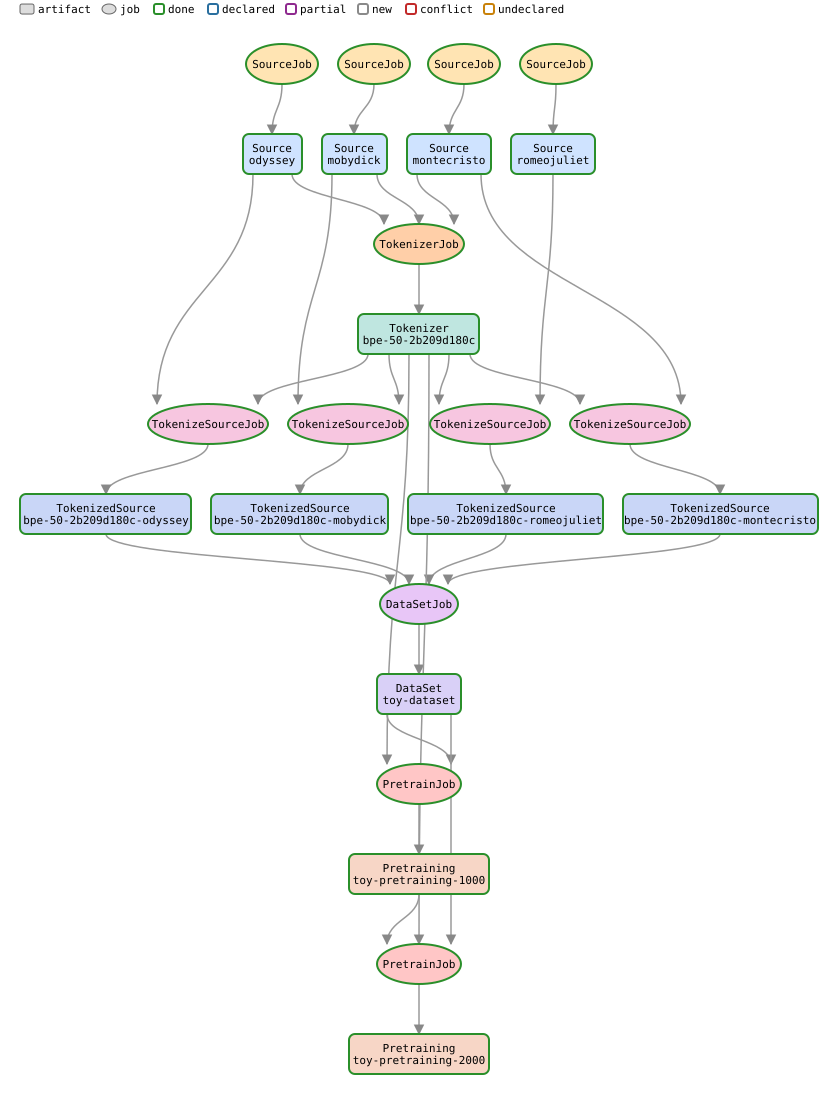

In [21]:
visualize(pretraining_plan, root)  # everything below leg2 is done

And the conflict from above, drawn: `clash` lands on `leg2`'s folder with a
different learning rate, so that one node -- and only that node -- comes back
red. Its dependencies stay done; nothing about them is in question.

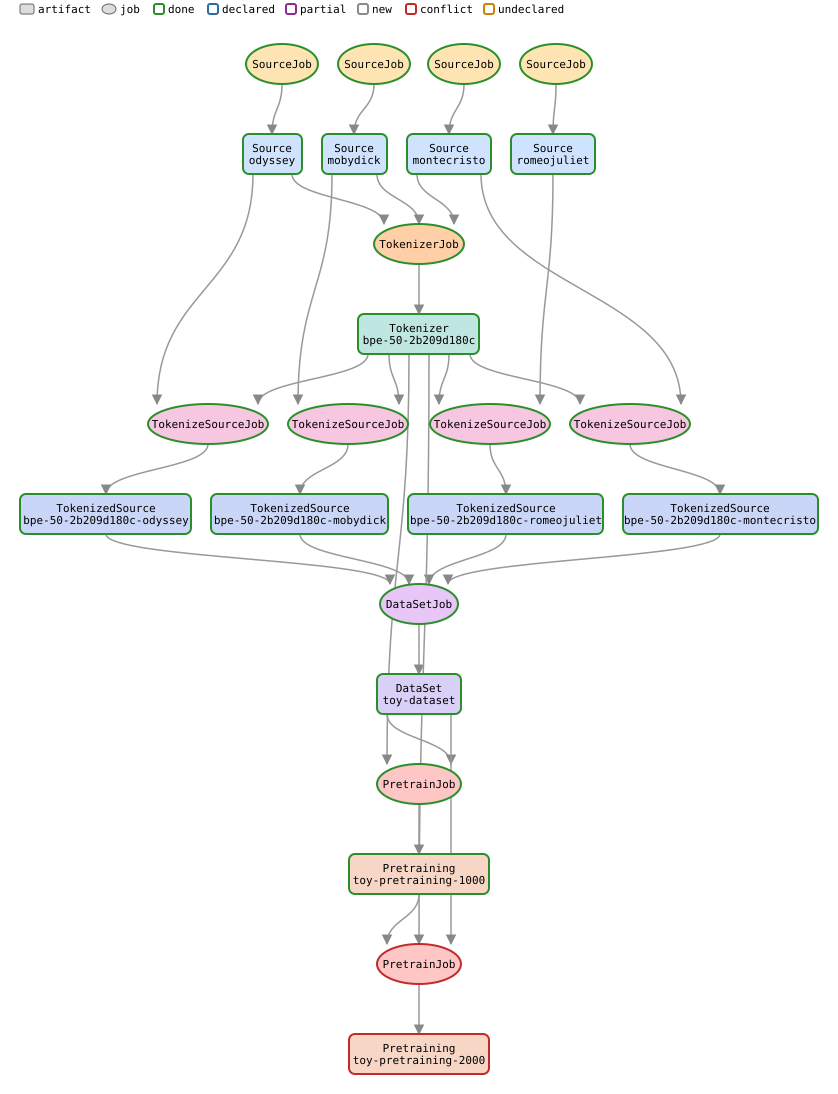

In [22]:
visualize(resolve(clash), root)